# Imports and Reading data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_csv('STO-const_decay-1m.csv')

# Data understanding

In [3]:
df.shape

# Check the number of rows and columns.

(1000000, 5)

In [4]:
df.head(5)

,optimizer_gain,dither_amplitude,dither_frequency,converged,convergence_time
0,0.000043,8.147237,18.115839,0,NaN
1,0.000031,9.133759,12.647185,0,NaN
2,0.613104,2.784982,10.937630,0,NaN
3,0.712794,9.648885,3.152262,0,NaN
4,0.100323,9.571669,9.707513,0,NaN


In [5]:
df.dtypes

optimizer_gain      float64
dither_amplitude    float64
dither_frequency    float64
converged             int64
convergence_time    float64
dtype: object

# Data preparation

In [6]:
df.isna().sum()

# Check for missing values before deciding whether rows need to be removed.

optimizer_gain           0
dither_amplitude         0
dither_frequency         0
converged                0
convergence_time    974813
dtype: int64

# Feature understanding

Text(0, 0.5, 'Counts')

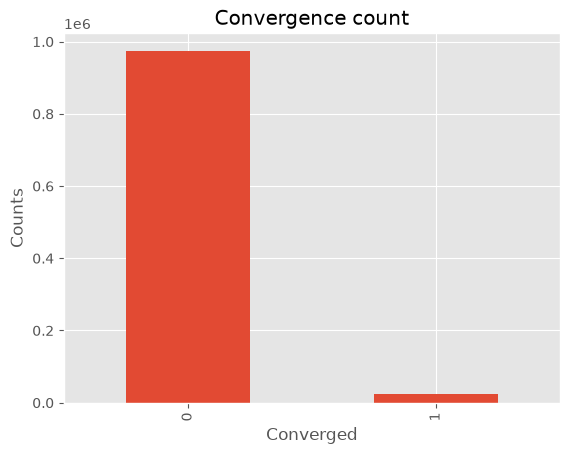

In [7]:
cv = df['converged'].value_counts().head(10).plot(kind = 'bar', title = 'Convergence count')

cv.set_xlabel('Converged')
cv.set_ylabel('Counts')

# Inspect the balance between converged and non-converged samples.

Text(0, 0.5, 'Frequency')

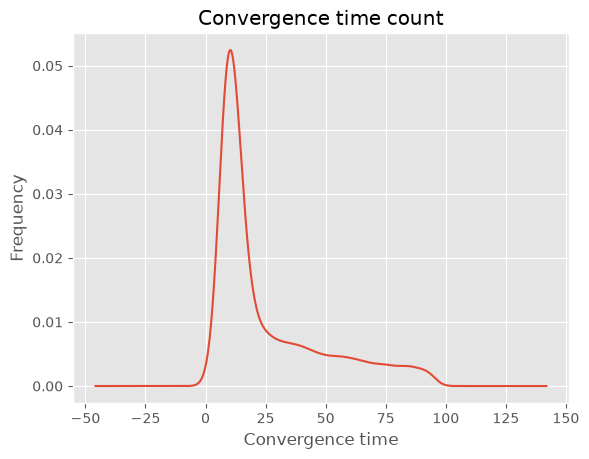

In [8]:
ct = df['convergence_time'].plot(kind = 'kde',
                title = 'Convergence time count')
ct.set_xlabel('Convergence time')
ct.set_ylabel('Frequency')

# Inspect the distribution of convergence times.

In [9]:
sum(df['convergence_time'] < 10)

# Count combinations with convergence time below 10 seconds.

7102

In [10]:
sum(df['convergence_time'] < 5)

# Count combinations with convergence time below 5 seconds.


533

# Feature relationships

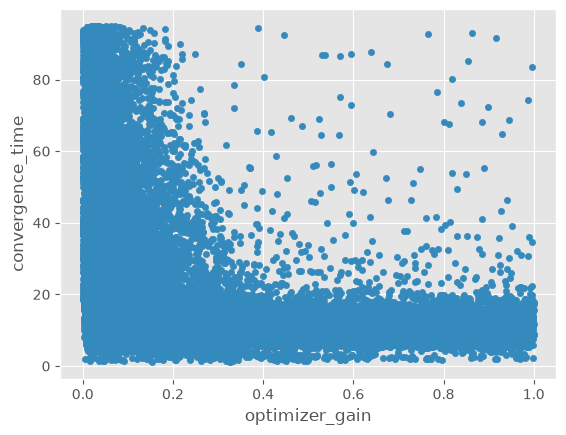

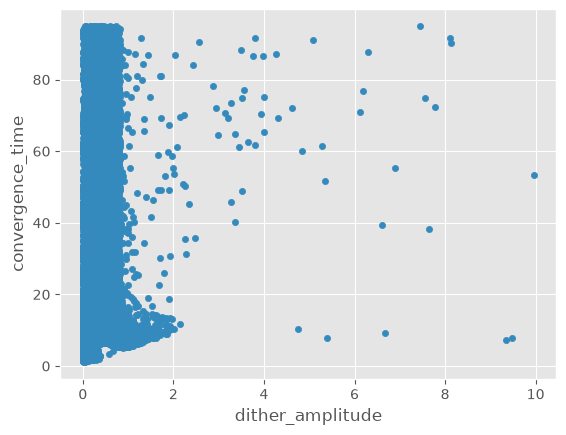

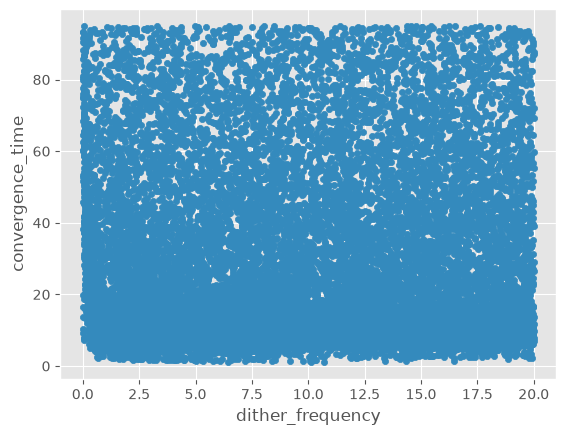

In [11]:
for i in range (df.shape[1] - 2):
    df.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


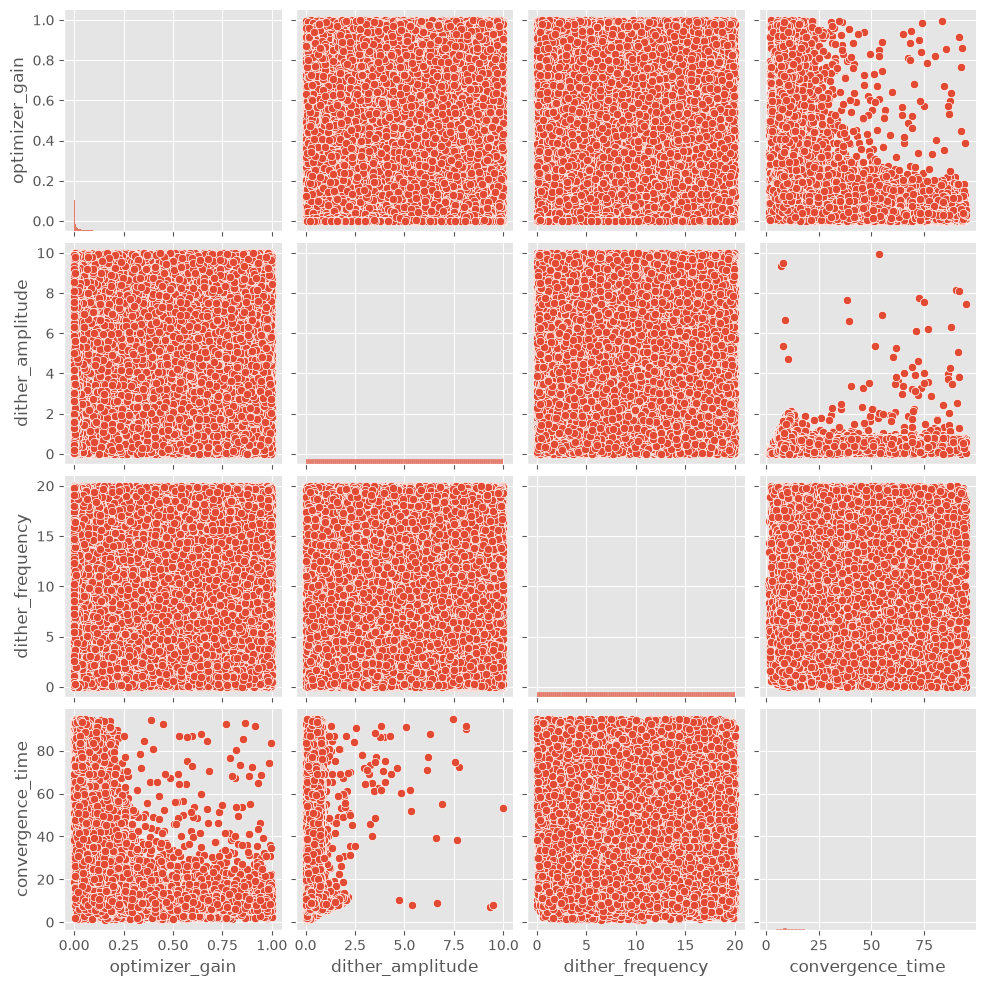

In [12]:
sns.pairplot(df,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

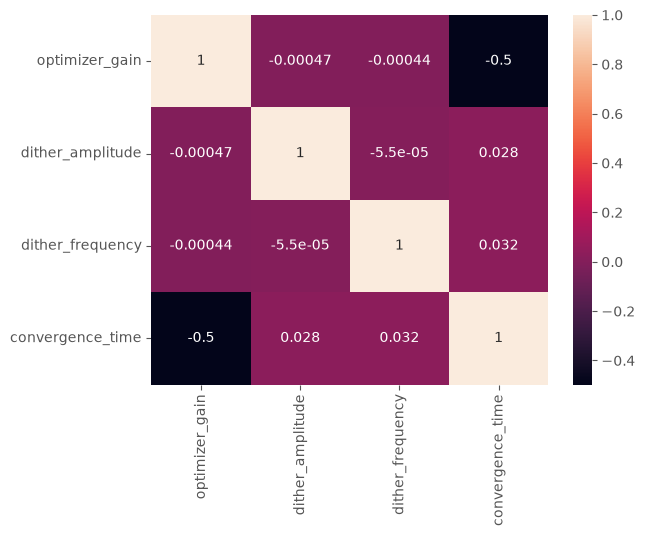

In [13]:
sns.heatmap(df.drop(columns = 'converged').corr(), annot = True)


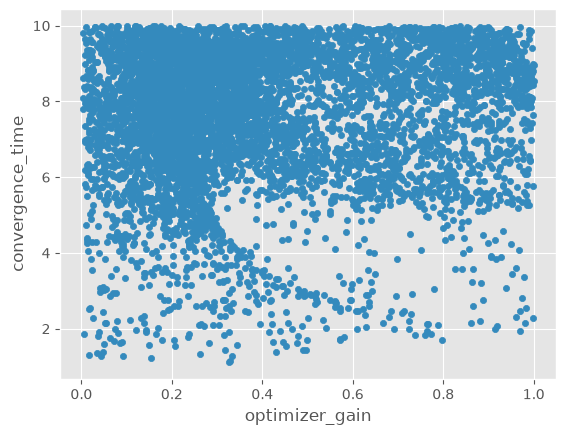

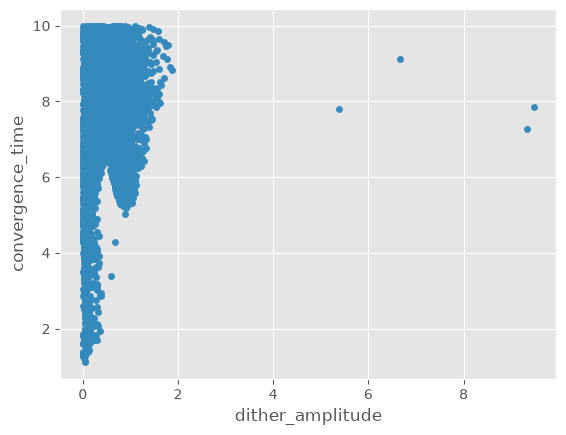

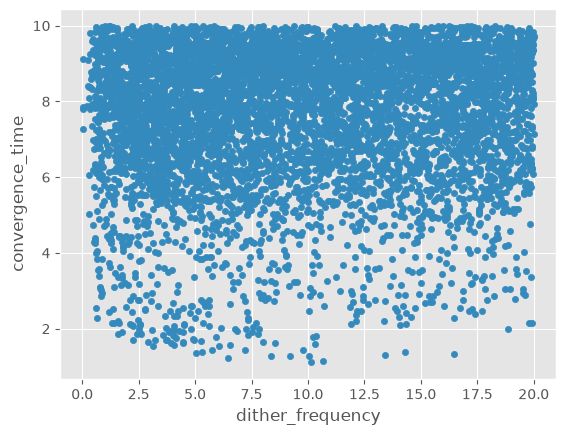

In [14]:
dfcut = df[df['convergence_time'] < 10]
for i in range (dfcut.shape[1] - 2):
    dfcut.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


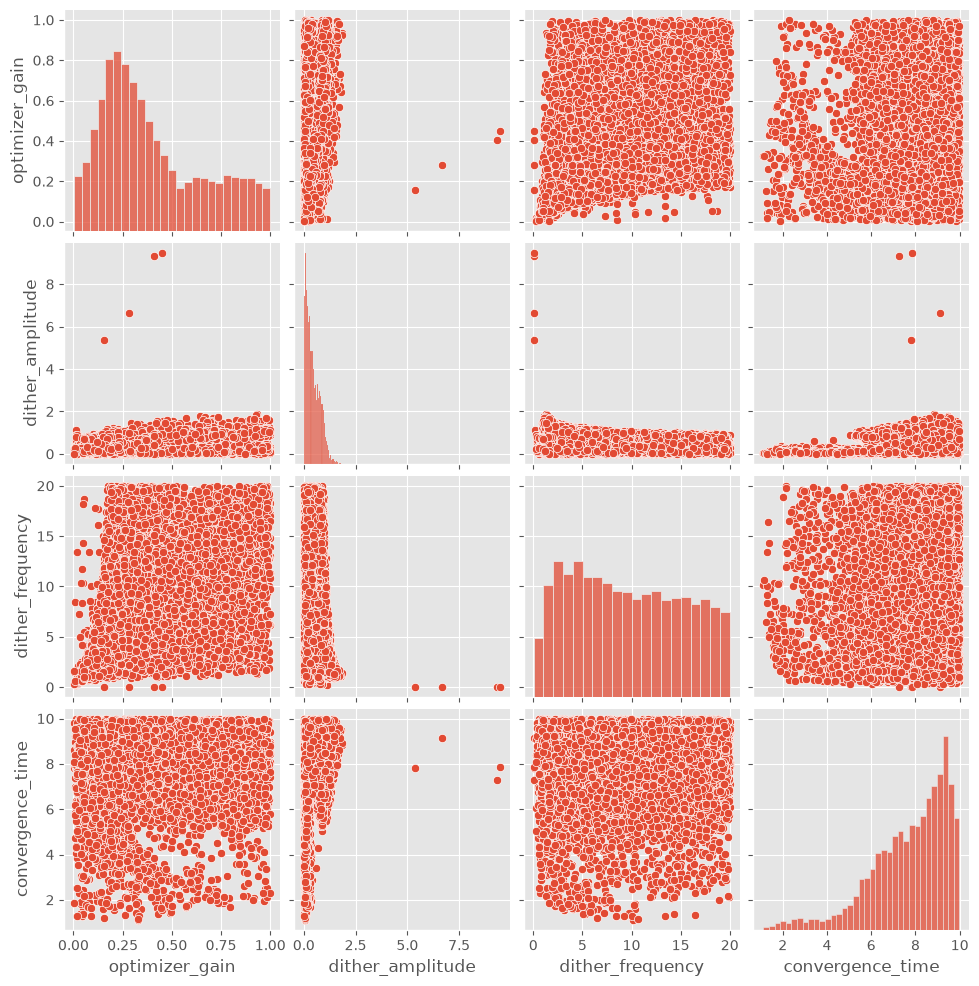

In [15]:
sns.pairplot(dfcut,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

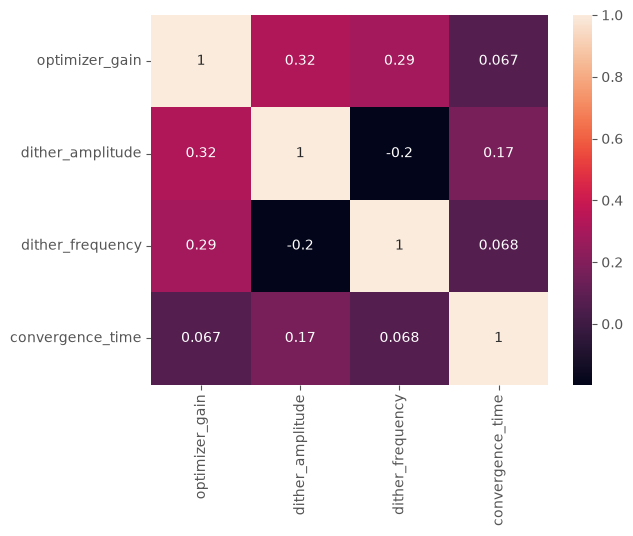

In [16]:
sns.heatmap(dfcut.drop(columns = 'converged').corr(), annot = True)


I think it would be useful to plot a 3d plot to visualize where the false predictions are.

# Visualization

In [ ]:
import plotly.express as px

In [ ]:
fig1m = px.scatter_3d(df,
                    x = 'optimizer_gain',
                    y = 'dither_amplitude',
                    z = 'dither_frequency',
                    color = 'convergence_time',
                    title = '3D scatter',
                    labels = {'optimizer_gain' : 'Optimizer gain',
                              'dither_amplitude' : 'Dither amplitude',
                              'dither_frequency' : 'Dither Frequency'})
fig1m.update_traces(marker=dict(size=3))
fig1m.show()

In [ ]:
# Exporting the plot (put it comment as I would run the notebook all over every time I open)
# fig1m.write_html("3dscatter1m.html")

# Modelling: Classification

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



Defining models

In [18]:
model1 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

model2 = Sequential(
    [
        Dense(64, activation='relu', name="L1"),
        Dense(32, activation='relu', name="L2"),
        Dense(16, activation='relu', name="L3"),
        Dense(1, activation = 'linear', name = "L4")  
    ]
)

In [19]:
# Adding more features to the dataset
df['log10gain'] = np.log10(df['optimizer_gain'])
df['sinfre'] = np.sin(df['dither_frequency'])
df['product'] = df['optimizer_gain'] * df['dither_amplitude'] * df['sinfre']

In [20]:
# Create training sets

X = df.drop(columns=['convergence_time', 'converged'])
y = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [21]:
# Train with model 1

model1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history1 = model1.fit(X_train, 
                     y_train, 
                     epochs=300, 
                     validation_data=(X_cv, y_cv))
plt.plot(history1.history['loss'], label='train loss')
plt.plot(history1.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

Epoch 1/300
18750/18750 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step - loss: 0.0143 - val_loss: 0.0104
Epoch 2/300
18750/18750 ━━━━━━━━━━━━━━━━━━━━ 18s 955us/step - loss: 0.0102 - val_loss: 0.0078
Epoch 3/300
18750/18750 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0099 - val_loss: 0.0102
Epoch 4/300
18750/18750 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 0.0094 - val_loss: 0.0101
Epoch 5/300
18750/18750 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0091 - val_loss: 0.0073
Epoch 6/300
18750/18750 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 0.0088 - val_loss: 0.0078
Epoch 7/300
 7648/18750 ━━━━━━━━━━━━━━━━━━━━ 8s 759us/step - loss: 0.0086

KeyboardInterrupt: 

In [ ]:
logits1 = model1.predict(X_cv)
probs1 = tf.sigmoid(logits1).numpy() # convert logit to probability
y_pred1 = (probs1 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy1 = accuracy_score(y_cv, y_pred1)
print(f"CV accuracy: {accuracy1:.3f}")


In [ ]:
print(confusion_matrix(y_cv, y_pred1))
print(classification_report(y_cv, y_pred1))

In [ ]:
train_logits1 = model1.predict(X_train)
train_probs1 = tf.sigmoid(train_logits1).numpy()
train_pred1 = (train_probs1 > 0.5).astype(int).flatten()
train_acc1 = accuracy_score(y_train, train_pred1)
print(f"Train accuracy: {train_acc1:.3f}")

Try a larger model to see whether it improves accuracy.

In [ ]:
# Train with model 2

model2.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history2 = model2.fit(X_train, 
                     y_train, 
                     epochs=300, 
                     validation_data=(X_cv, y_cv))
plt.plot(history2.history['loss'], label='train loss')
plt.plot(history2.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [ ]:
logits2 = model2.predict(X_cv)
probs2 = tf.sigmoid(logits2).numpy() # convert logit to probability
y_pred2 = (probs2 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy2 = accuracy_score(y_cv, y_pred2)
print(f"CV accuracy: {accuracy2:.3f}")

In [ ]:
print(confusion_matrix(y_cv, y_pred2))
print(classification_report(y_cv, y_pred2))


In [ ]:
train_logits2 = model2.predict(X_train)
train_probs2 = tf.sigmoid(train_logits2).numpy()
train_pred2 = (train_probs2 > 0.5).astype(int).flatten()
train_acc2 = accuracy_score(y_train, train_pred2)
print(f"Train accuracy: {train_acc2:.3f}")

I think there is still room for improvement, but we would have to analyse the wrong predictions first.

In [ ]:
# Find where the false positives are
false_positive1 = (y_pred1 == 1) & (y_cv == 0)
X_cv1_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv1_df[false_positive1].describe())

false_positive2 = (y_pred2 == 1) & (y_cv == 0)
X_cv2_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv2_df[false_positive2].describe())

In [ ]:
# Merge the false positives into 1 table

fp1 = X_cv1_df[false_positive1]
fp2 = X_cv2_df[false_positive2]

fp = pd.concat([fp1, fp2], ignore_index=True)
print(fp.describe())

In [ ]:
# Drop duplicated rows of fp

fp = fp.loc[~fp.duplicated()].reset_index(drop = True)
print(fp.describe())

In [ ]:
# Find where the false negatives are
false_negative1 = (y_pred1 == 0) & (y_cv == 1)
X_cv1_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv1_df[false_negative1].describe())

false_negative2 = (y_pred2 == 0) & (y_cv == 1)
X_cv2_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv2_df[false_negative2].describe())

In [ ]:
# Merge the false negatives into 1 table

fn1 = X_cv1_df[false_negative1]
fn2 = X_cv2_df[false_negative2]

fn = pd.concat([fn1, fn2], ignore_index=True)
print(fn.describe())

In [ ]:
# Drop duplicated rows of fn

fn = fn.loc[~fn.duplicated()].reset_index(drop = True)
print(fn.describe())

In [ ]:
fp

I realized that I did not pay enough attention to thhe dither amplitude. 
I will generate another dataset with wider range of dither amplitude (and dither frequency) to hopefully get a symmetric 3d plot.
I need to increase the range of all 3 parameters.

    % ESC parameters range
    optimizer_gain_range   = [1e-4, 0.15];
    dither_amplitude_range = [0.01, 1];
    dither_frequency_range = [0.1, 1.5];  

It seems like the dither frequency still have plenty of space to increase
The optimizer gain depends on the convergence time allowed (in this case 100 seconds) so it can go really low.

    optimizer_gain_range   = [1e-5, 0.25];
    dither_amplitude_range = [1e-5, 2.5];
    dither_frequency_range = [1e-5, 3];  

    need checking

The points are probably unnecersarily densed. 
I would keep the same the number of combinations and increase the range to figure out the shape first 
The dither frequency still has a lot of space, probably up to 20 (?) and even lower
Optimizer gain can probably go up to 1
Dither amplitude goes much lower and up to 5+

1M is too large for the browser so I can only choose randomly 500k

1. It seems like doesn't matter how long I go with the amplitude and how high with the frequency, they would still have nice convergence time
2. There are some "random points" that would "unexpectedly" converge

    optimizer_gain_range   = [1e-50, 5];
    dither_amplitude_range = [1e-708, 20];
    dither_frequency_range = [1e-708, 100];  